# Notebook 11: Movie clustering and regression using ABT

## Features:
- ✅ Use of embedding to create semantic vectors for each movie
- ✅ Semantic clustering
- ✅ Budget and Revenue to predict popularity using regression

## What's New in This Update:


## Tools Available:
1. embedding tool - Use embedding to convert unstructured content to structured vectors
2. Use of network graphs to assemble clusters
3. regression tool - where it can provide value

## Installation

In [2]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 11.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [81]:
%pip install sentence-transformers faiss-cpu networkx matplotlib seaborn

print("✓ Packages installed")

Note: you may need to restart the kernel to use updated packages.
✓ Packages installed


## Imports

In [1]:
import pandas as pd
import numpy as np
import faiss
import networkx as nx
import matplotlib.pyplot as plt
from openai import AzureOpenAI
import os, json
from dotenv import load_dotenv
#from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.tools import tool
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from ai_course_utils import load_llm_from_env, load_use_case_config, display_config
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

print("✓ Imports successful")

NS: what it reads is:  gpt-4.1-mini
✓ Imports successful


## Set up environment and OpenAI

In [2]:
# Load environment
load_dotenv()

True

In [3]:
os.getenv("LLM_MODEL_VERSION")

'2024-12-01-preview'

In [4]:
# 1. Setup OpenAI Client
client = AzureOpenAI(
    api_version=os.getenv("LLM_MODEL_VERSION"),
    azure_endpoint=os.getenv("AZURE_INFERENCE_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY")
)
response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {"role": "system", "content": "You are a helpful assistant"},
                {"role": "user", "content": "What is AI?"}
            ],
            temperature=0.7
        )
response

ChatCompletion(id='chatcmpl-DC8KHGHx69KPM7CtZ6bmZf2YT7dc5', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think, learn, and solve problems like humans. It involves creating computer systems capable of performing tasks that typically require human intelligence, such as understanding natural language, recognizing patterns, making decisions, and adapting to new information. AI can range from simple algorithms to advanced systems like machine learning, deep learning, and neural networks.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None), content_filter_results={'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_code': {'filtered': False, 'detected': False}, 'protected_material_text': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 's

# Load the CSV

In [5]:

# Load the CSV
df = pd.read_csv("../data/outputs/ABT_Enriched/movie_abt_enriched.csv")
df



,Unnamed: 0,movieId,title,movielens_genres,avg_rating,number_of_viewers,imdbId,tmdbId,adult,backdrop_path,...,runtime,spoken_languages,status,tagline,video,vote_average,vote_count,success,status_code,status_message
0,0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,3.920930,215.0,114709,862.0,False,/bSoOThXLrbgtphS2eZjwy2xYwVt.jpg,...,81.0,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,The adventure takes off when toys come to life!,False,7.970,19556.0,NaN,NaN,NaN
1,1,2,Jumanji,Adventure|Children|Fantasy,3.431818,110.0,113497,8844.0,False,/qSxeCfWUUyht9hZgaaYmtPtTkw2.jpg,...,104.0,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,It's a jungle in here.,False,7.244,11112.0,NaN,NaN,NaN
2,2,3,Grumpier Old Men,Comedy|Romance,3.259615,52.0,113228,15602.0,False,/1o4vuCHpmd4DXofMYDUwpnhKiuy.jpg,...,101.0,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Still Yelling. Still Fighting. Still Ready for...,False,6.482,415.0,NaN,NaN,NaN
3,3,4,Waiting to Exhale,Comedy|Drama|Romance,2.357143,7.0,114885,31357.0,False,/jZjoEKXMTDoZAGdkjhAdJaKtXSN.jpg,...,127.0,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Friends are the people who let you be yourself...,False,6.247,192.0,NaN,NaN,NaN
4,4,5,Father of the Bride Part II,Comedy,3.071429,49.0,113041,11862.0,False,/lEsjVrGU21BeJjF5AF9EWsihDpw.jpg,...,106.0,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Just when his world is back to normal... he's ...,False,6.273,790.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,9737,193581,Black Butler: Book of the Atlantic,Action|Animation|Comedy|Fantasy,4.000000,1.0,5476944,432131.0,False,/clFQR5zwzDrayMVVe7axo0YLFfh.jpg,...,100.0,"[{'english_name': 'Japanese', 'iso_639_1': 'ja...",Released,NaN,False,7.500,98.0,NaN,NaN,NaN
9738,9738,193583,"No Game, No Life: Zero",Animation|Comedy|Fantasy,3.500000,1.0,5914996,445030.0,False,/b0dP4lPgK8Dg0tQEPx6z73jRURA.jpg,...,106.0,"[{'english_name': 'Japanese', 'iso_639_1': 'ja...",Released,NaN,False,7.800,426.0,NaN,NaN,NaN
9739,9739,193585,Flint,Drama,3.500000,1.0,6397426,479308.0,False,/tcM6XoTYKATJyNTIuGPk4yh0g6N.jpg,...,96.0,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,False,6.800,18.0,NaN,NaN,NaN
9740,9740,193587,Bungo Stray Dogs: Dead Apple,Action|Animation,3.500000,1.0,8391976,483455.0,False,/vjnS4iu0SdwXm2LLqZGNCfpId9t.jpg,...,90.0,"[{'english_name': 'Japanese', 'iso_639_1': 'ja...",Released,An underworld is rising.,False,8.125,184.0,NaN,NaN,NaN


# Conduct covariance ananlysis and normalize data

In [6]:
# 1. Define the specific list of columns we want to analyze
quantified_cols = [
    'avg_rating', 
    'number_of_viewers', 
    'budget', 
    'popularity', 
    'revenue', 
    'vote_average', 
    'vote_count'
]

# 2. Create a new dataframe with just these columns
# We use .copy() to ensure we aren't modifying the original 'df' by accident
numeric_df = df[quantified_cols].copy()

# 3. Explicitly convert every column to float
# This ensures that math operations like normalization won't hit "integer division" issues
for col in quantified_cols:
    numeric_df[col] = numeric_df[col].astype(float)

print(f"Successfully isolated and converted {len(quantified_cols)} columns to float.")
display(numeric_df.dtypes)

Successfully isolated and converted 7 columns to float.


avg_rating           float64
number_of_viewers    float64
budget               float64
popularity           float64
revenue              float64
vote_average         float64
vote_count           float64
dtype: object

In [7]:
# 2. Apply Min-Max Normalization
# Formula: (value - min) / (max - min)
numeric_df_min = numeric_df.min()
numeric_df_max = numeric_df.max()

normalized_df = (numeric_df - numeric_df_min) / (numeric_df_max - numeric_df_min)

print("Data successfully normalized to 0-1 range.")
print("Example of normalized values:")
display(normalized_df.head())

Data successfully normalized to 0-1 range.
Example of normalized values:


,avg_rating,number_of_viewers,budget,popularity,revenue,vote_average,vote_count
0,0.760207,0.652439,0.079156,0.203986,0.137209,0.895204,0.502686
1,0.651515,0.332317,0.171504,0.051912,0.089893,0.813658,0.285633
2,0.613248,0.155488,0.065963,0.015101,0.024455,0.728069,0.010668
3,0.412698,0.018293,0.042216,0.026906,0.027859,0.701674,0.004935
4,0.571429,0.146341,0.000000,0.022201,0.026198,0.704594,0.020307


In [8]:
# Calculate covariance on the 0-1 scaled data
normalized_cov = normalized_df.corr()

print("--- Normalized Correlation Matrix ---")
display(normalized_cov)

# Save to CSV for the students to keep
normalized_cov.to_csv("normalized_covariance.csv")

--- Normalized Correlation Matrix ---


,avg_rating,number_of_viewers,budget,popularity,revenue,vote_average,vote_count
avg_rating,1.000000,0.127259,-0.091853,0.061055,0.002808,0.531249,0.098636
number_of_viewers,0.127259,1.000000,0.284637,0.550794,0.441132,0.284184,0.622668
budget,-0.091853,0.284637,1.000000,0.519528,0.763444,0.000863,0.620134
popularity,0.061055,0.550794,0.519528,1.000000,0.636366,0.261186,0.793933
revenue,0.002808,0.441132,0.763444,0.636366,1.000000,0.140156,0.782245
vote_average,0.531249,0.284184,0.000863,0.261186,0.140156,1.000000,0.299493
vote_count,0.098636,0.622668,0.620134,0.793933,0.782245,0.299493,1.000000


# Create Heatmap

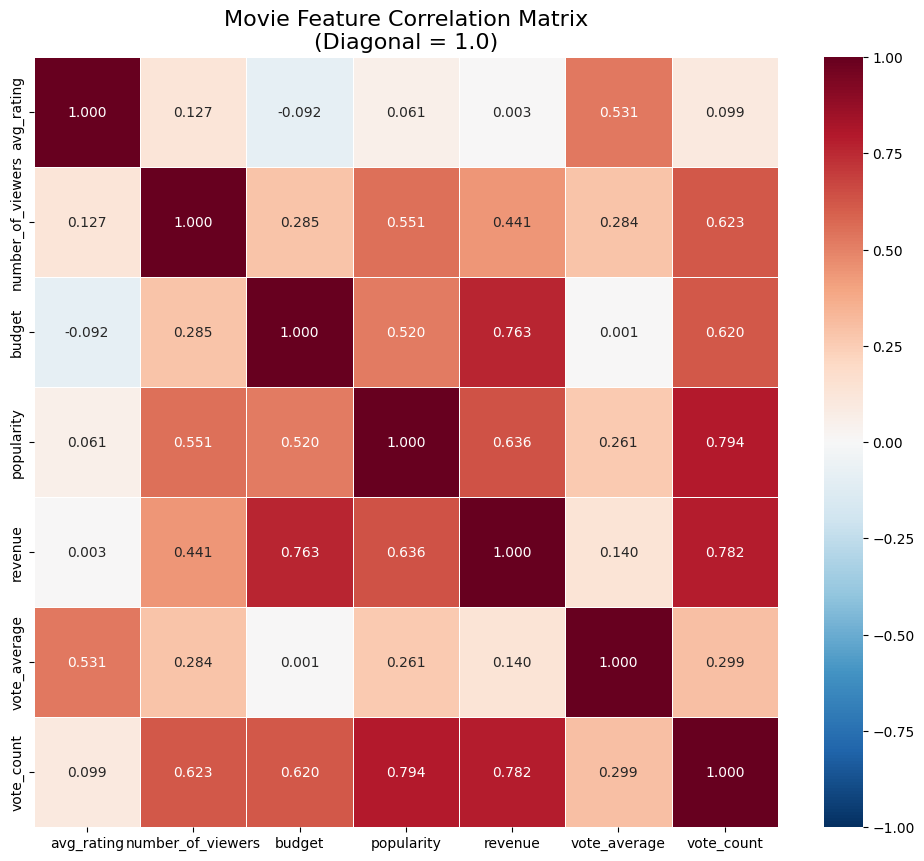

In [9]:

# 1. Calculate the Correlation (Standardized relationship)
# Note: Correlation is scale-invariant, so it works perfectly with our 0-1 data
corr_matrix = normalized_df.corr()

# 2. Setup the visualization
plt.figure(figsize=(12, 10))

# 3. Create the Heatmap
# vmin and vmax set the scale to the mathematical limits of correlation
# cmap='RdBu_r' uses Red for positive and Blue for negative correlations
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".3f", 
            cmap="RdBu_r", 
            center=0,
            vmin=-1, 
            vmax=1,
            linewidths=.5)

plt.title("Movie Feature Correlation Matrix\n(Diagonal = 1.0)", fontsize=16)
plt.show()

# Set up regression features and target

In [10]:
# 1. Combine all potential features and target into one temporary dataframe
# This ensures that when we drop a row, it's dropped from both X and y simultaneously
#  Define our features (X) and target (y)
# We combine our normalized numeric columns with the genre columns

genre_cols = [col for col in df.columns if col.startswith('Genre_')]
feature_cols = ['revenue', 'budget', 'avg_rating', 'vote_count'] + genre_cols
X = pd.concat([normalized_df[['revenue', 'budget', 'avg_rating', 'vote_count']], 
               df[genre_cols]], axis=1)
y = normalized_df['popularity']

cleaning_df = pd.concat([
    normalized_df[['revenue', 'budget', 'avg_rating', 'vote_count']], 
    df[genre_cols],
    y # our target: popularity
], axis=1)

# 2. Drop rows with any missing values
# We'll also store how many we lost for the lesson notes
initial_count = len(cleaning_df)
cleaning_df = cleaning_df.dropna()
final_count = len(cleaning_df)

print(f"Scrubbing Complete:")
print(f"• Removed {initial_count - final_count} movies with missing values.")
print(f"• {final_count} movies remaining for the model.")

# 3. Re-separate into X and y
X_clean = cleaning_df.drop(columns=['popularity'])
y_clean = cleaning_df['popularity']

Scrubbing Complete:
• Removed 139 movies with missing values.
• 9603 movies remaining for the model.


In [11]:
# 2. Split the data manually as requested
# Training set: First 1,000 rows
X_train = X_clean.iloc[0:1000]
y_train = y_clean.iloc[0:1000]

# Testing set: Next 200 rows
X_test = X_clean.iloc[1000:1200]
y_test = y_clean.iloc[1000:1200]

print(f"Training on: {len(X_train)} movies")
print(f"Testing on: {len(X_test)} movies")

Training on: 1000 movies
Testing on: 200 movies


# Initialize and Train Regression Model

In [12]:
# 3. Initialize and Train
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# 4. Make Predictions on both sets
train_preds = regressor.predict(X_train)
test_preds = regressor.predict(X_test)

# 5. Calculate Metrics
train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"--- Model Performance ---")
print(f"Training R² (Learning Fit): {train_r2:.4f}")
print(f"Testing R² (Generalization): {test_r2:.4f}")

--- Model Performance ---
Training R² (Learning Fit): 0.7606
Testing R² (Generalization): 0.6677


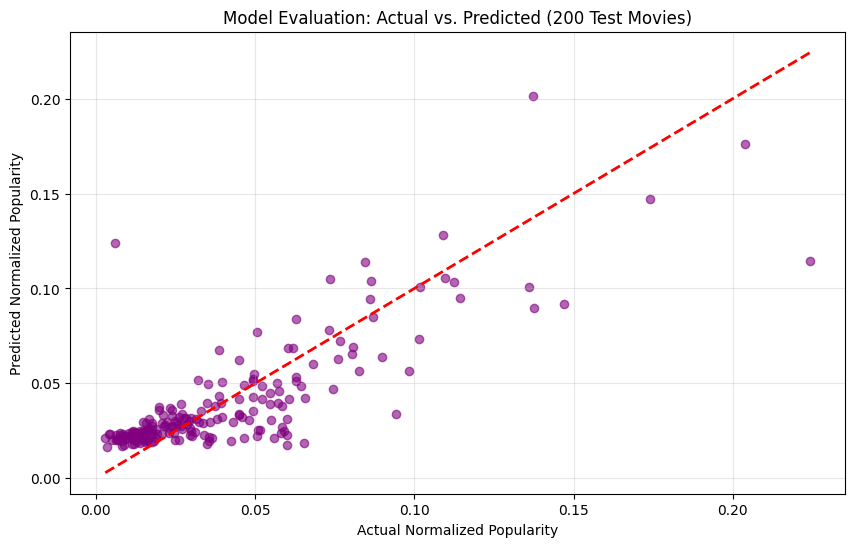

In [13]:
plt.figure(figsize=(10, 6))

# Plotting the 200 test movies
plt.scatter(y_test, test_preds, alpha=0.6, color='purple')

# Add a 45-degree line (Perfect Prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Normalized Popularity")
plt.ylabel("Predicted Normalized Popularity")
plt.title("Model Evaluation: Actual vs. Predicted (200 Test Movies)")
plt.grid(True, alpha=0.3)
plt.show()

# Filter movie data for min viewer count and rating

In [14]:
# 1. Filter: Movies must have at least 5 viewers AND a rating of 3.0 or higher
# Replacing 'view_count' and 'rating' with the exact column names from your CSV
filtered_df = df[
    (df['number_of_viewers'] >= 5) & 
    (df['avg_rating'] >= 3.0)
].copy()

# 2. Cleanup: Remove rows with empty overviews for the API
filtered_df = filtered_df.dropna(subset=['overview'])

# Convert to a list of JSON-like dictionaries
# We'll keep just the columns we need for the lesson
movie_data = filtered_df[['title', 'overview']].to_dict(orient='records')

print(f"Original movies: {len(df)}")
print(f"Movies after filtering: {len(filtered_df)}")
print(f"Removed {len(df) - len(filtered_df)} movies due to low viewers/ratings/empty overviews.")
print(f"Total Movies loaded: {len(movie_data)}")
print("Example Movie Object:")
print(movie_data[0])

Original movies: 9742
Movies after filtering: 2763
Removed 6979 movies due to low viewers/ratings/empty overviews.
Total Movies loaded: 2763
Example Movie Object:
{'title': 'Toy Story', 'overview': "Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences."}


# Vectorize movie overviews

In [ ]:
print("Starting vectorization loop...")

for i, movie in enumerate(movie_data):
    # Call AzureOpenAI for the individual overview
    response = client.embeddings.create(
        input=movie['overview'],
        model="text-embedding-3-small"
    )
    
    # Store the vector directly in the JSON object
    movie['vector'] = response.data[0].embedding
    
    # Progress tracker for the students
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1} / {len(movie_data)} movies...")

print("✓ All movies now contain embedding vectors.")

Starting vectorization loop...
Processed 100 / 2763 movies...
Processed 200 / 2763 movies...
Processed 300 / 2763 movies...
Processed 400 / 2763 movies...
Processed 500 / 2763 movies...
Processed 600 / 2763 movies...
Processed 700 / 2763 movies...
Processed 800 / 2763 movies...
Processed 900 / 2763 movies...
Processed 1000 / 2763 movies...
Processed 1100 / 2763 movies...
Processed 1200 / 2763 movies...
Processed 1300 / 2763 movies...
Processed 1400 / 2763 movies...
Processed 1500 / 2763 movies...
Processed 1600 / 2763 movies...
Processed 1700 / 2763 movies...
Processed 1800 / 2763 movies...
Processed 1900 / 2763 movies...
Processed 2000 / 2763 movies...
Processed 2100 / 2763 movies...
Processed 2200 / 2763 movies...
Processed 2300 / 2763 movies...
Processed 2400 / 2763 movies...
Processed 2500 / 2763 movies...
Processed 2600 / 2763 movies...
Processed 2700 / 2763 movies...
✓ All movies now contain embedding vectors.


In [16]:
# Define your output path
output_path = "../data/outputs/ABT_Enriched/movie_abt_enriched_vectorized.json"

# Open the file in 'w' (write) mode
with open(output_path, "w") as json_file:
    # Use .dump() to save the list directly to the file
    # indent=4 makes the file human-readable for your students
    json.dump(movie_data, json_file, indent=4)

print(f"✓ Successfully saved {len(movie_data)} vectorized movies to {output_path}")

✓ Successfully saved 2763 vectorized movies to ../data/outputs/ABT_Enriched/movie_abt_enriched_vectorized.json


# Similarity Analysis

In [17]:
similarity_pairs = []

# Nested loop to compare movie 'i' with movie 'j'
for i in range(len(movie_data)):
    for j in range(i + 1, len(movie_data)):
        
        # Calculate Dot Product (Cosine Similarity)
        vec_a = movie_data[i]['vector']
        vec_b = movie_data[j]['vector']
        score = np.dot(vec_a, vec_b)
        
        # Create a new JSON for this relationship
        comparison = {
            "movie_a": movie_data[i]['title'],
            "movie_b": movie_data[j]['title'],
            "overview_a": movie_data[i]['overview'][:100] + "...",
            "overview_b": movie_data[j]['overview'][:100] + "...",
            "similarity": round(float(score), 4),
            "index_a": i,
            "index_b": j
        }
        similarity_pairs.append(comparison)

print(f"Generated {len(similarity_pairs)} total comparison pairs.")

Generated 3815703 total comparison pairs.


Total Pairs Analyzed: 3,815,703
Mean Similarity: 0.2198
Median Similarity: 0.2158
Standard deviation: 0.0804
Minimum Similarity: -0.1038
Maximum Similarity: 1.0000


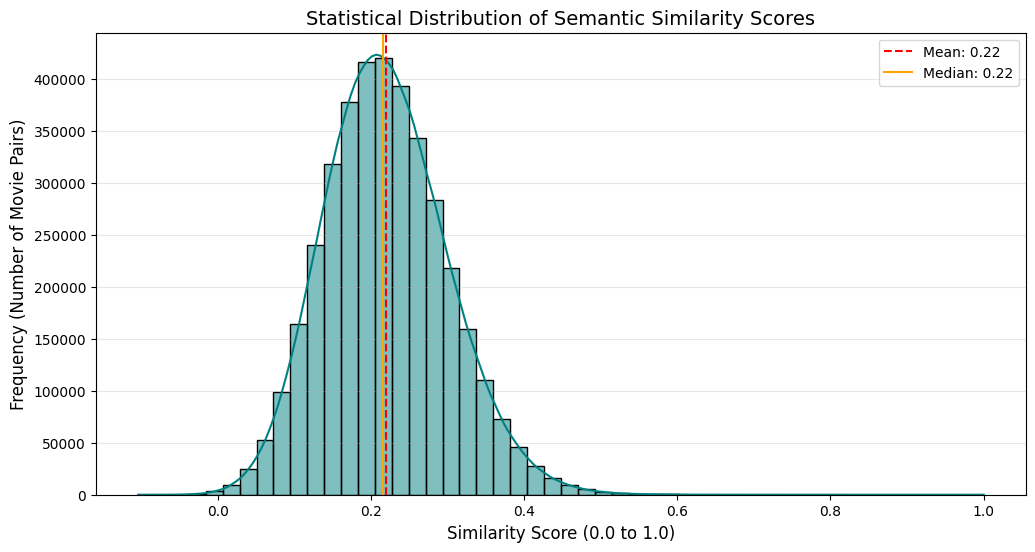

In [19]:

# Extract all similarity scores into a simple list
all_scores = [pair['similarity'] for pair in similarity_pairs]

# Calculate basic statistics for the lesson
mean_score = np.mean(all_scores)
median_score = np.median(all_scores)
std_dev = np.std(all_scores)

print(f"Total Pairs Analyzed: {len(all_scores):,}")
print(f"Mean Similarity: {mean_score:.4f}")
print(f"Median Similarity: {median_score:.4f}")
print(f"Standard deviation: {std_dev:.4f}")
print(f"Minimum Similarity: {min(all_scores):.4f}")
print(f"Maximum Similarity: {max(all_scores):.4f}")

# Create the Visualization
plt.figure(figsize=(12, 6))

# Use a histogram with a Kernel Density Estimate (KDE) line
sns.histplot(all_scores, bins=50, kde=True, color='teal')

# Add vertical lines for Mean and Median
plt.axvline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.2f}')
plt.axvline(median_score, color='orange', linestyle='-', label=f'Median: {median_score:.2f}')

# Add current cutoff line if you have one defined
if 'cutoff' in locals():
    plt.axvline(cutoff, color='black', linewidth=2, label=f'Current Cutoff: {cutoff}')

plt.title("Statistical Distribution of Semantic Similarity Scores", fontsize=14)
plt.xlabel("Similarity Score (0.0 to 1.0)", fontsize=12)
plt.ylabel("Frequency (Number of Movie Pairs)", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()



# Apply Similarity Cutoff

In [20]:
cutoff = 0.58 # Try changing this to see how clusters change!

# Remove all entries below the threshold
filtered_pairs = [p for p in similarity_pairs if p['similarity'] >= cutoff]

print(f"Pairs remaining after {cutoff} cutoff: {len(filtered_pairs)}")

Pairs remaining after 0.58 cutoff: 736


# Find Clusters with NetworkX

In [21]:
# Create the Graph
G = nx.Graph()

# Add an edge for every pair that survived the cutoff
for pair in filtered_pairs:
    G.add_edge(pair['index_a'], pair['index_b'])

# Find the clusters (connected components)
clusters = list(nx.connected_components(G))

print(f"Found {len(clusters)} distinct clusters.")

Found 224 distinct clusters.


# Display the Clusters

In [22]:
print(f"--- SEMANTIC CLUSTERS (Cutoff: {cutoff}) ---\n")
max_cluster_size = 0
for idx, cluster_nodes in enumerate(clusters):
    # Only show clusters with more than one movie
    if len(cluster_nodes) > 1:
        print(f"Cluster #{idx + 1} ({len(cluster_nodes)} movies):")
        if len(cluster_nodes) > max_cluster_size:
            max_cluster_size = len(cluster_nodes)
        for node_idx in cluster_nodes:
            print(f"  • {movie_data[node_idx]['title']}")
        print("-" * 40)
print("Max cluster size: ", max_cluster_size)

--- SEMANTIC CLUSTERS (Cutoff: 0.58) ---

Cluster #1 (3 movies):
  • Toy Story
  • Toy Story 3
  • Toy Story 2
----------------------------------------
Cluster #2 (2 movies):
  • Grumpier Old Men
  • Grumpy Old Men
----------------------------------------
Cluster #3 (2 movies):
  • Father of the Bride Part II
  • Father of the Bride
----------------------------------------
Cluster #4 (9 movies):
  • Heist
  • To Catch a Thief
  • Trading Places
  • Heat
  • White Men Can't Jump
  • Gone in Sixty Seconds
  • The Italian Job
  • The Town
  • Small Time Crooks
----------------------------------------
Cluster #5 (2 movies):
  • Sabrina
  • Sabrina
----------------------------------------
Cluster #6 (43 movies):
  • Spy
  • The Hunt for Red October
  • GoldenEye
  • Spectre
  • Mission: Impossible
  • The Bourne Ultimatum
  • On Her Majesty's Secret Service
  • The Spy Who Loved Me
  • Moonraker
  • The Man with the Golden Gun
  • RED 2
  • Tomorrow Never Dies
  • Mission: Impossible III
  

# Colorful Network Visualization

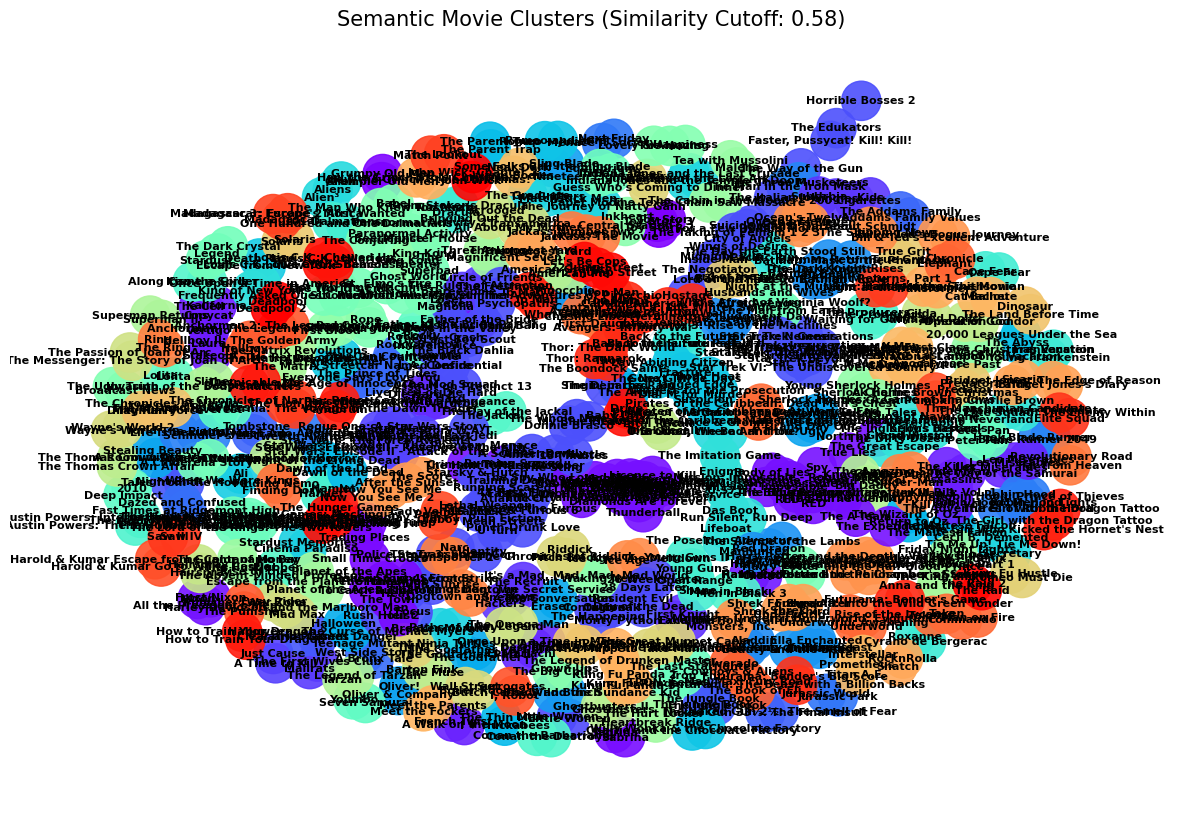

In [23]:
# 1. Initialize the plot
plt.figure(figsize=(15, 10))
plt.title(f"Semantic Movie Clusters (Similarity Cutoff: {cutoff})", fontsize=15)

# 2. Define the layout (Spring layout makes clusters 'clump' together)
pos = nx.spring_layout(G, k=0.15, seed=42)

# 3. Create a color map so each cluster has a unique color
# We'll map each node to its cluster ID
node_colors = []
for node in G.nodes():
    # Find which cluster this node belongs to
    for cluster_id, cluster_nodes in enumerate(clusters):
        if node in cluster_nodes:
            node_colors.append(cluster_id)
            break

# 4. Draw the elements
# Draw edges with transparency so the labels are readable
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')

# Draw nodes with the color map
nodes = nx.draw_networkx_nodes(G, pos, 
                               node_color=node_colors, 
                               cmap=plt.cm.rainbow, 
                               node_size=800,
                               alpha=0.9)

# 5. Add labels (Movie Titles)
# We use the titles stored in our movie_data JSON list
labels = {i: movie_data[i]['title'] for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

plt.axis('off')
plt.show()

In [24]:
# 1. Sort clusters by size (number of movies in the cluster), largest first
# We only want clusters with more than 1 movie
large_clusters = sorted([c for c in clusters if len(c) > 1], key=len, reverse=True)

print(f"Total multi-movie clusters found: {len(large_clusters)}")
print("Displaying the Top 5 Largest Clusters:\n")

# 2. Loop through and print the top 5 largest clusters
for i, cluster_nodes in enumerate(large_clusters[:5]):
    print(f"--- Cluster ID: {i+1} | Size: {len(cluster_nodes)} movies ---")
    
    # We'll print the titles and a tiny snippet of the overview for context
    for node_idx in list(cluster_nodes)[:10]: # Limit display to first 10 movies if cluster is huge
        title = movie_data[node_idx]['title']
        overview = movie_data[node_idx]['overview'][:75] + "..."
        print(f" • {title.upper()}")
        print(f"   Context: {overview}")
        
    if len(cluster_nodes) > 10:
        print(f"   [... and {len(cluster_nodes) - 10} more movies]")
    
    print("\n" + "="*50 + "\n")

Total multi-movie clusters found: 224
Displaying the Top 5 Largest Clusters:

--- Cluster ID: 1 | Size: 60 movies ---
 • THE LAST BOY SCOUT
   Context: Somewhere in Los Angeles, the city of broken dreams, a stripper is murdered...
 • L.A. CONFIDENTIAL
   Context: Three detectives in the corrupt and brutal L.A. police force of the 1950s u...
 • PULP FICTION
   Context: A burger-loving hit man, his philosophical partner, a drug-addled gangster'...
 • NARC
   Context: Narcotics Sergeant Nick Tellis, on leave after a trauma, is called back to ...
 • U TURN
   Context: When a desperate man’s car breaks down in a bizarre desert town while evadi...
 • THE NEGOTIATOR
   Context: The police try to arrest expert hostage negotiator Danny Roman, who insists...
 • TEQUILA SUNRISE
   Context: In a seaside California town, best friends Mac and Nick are on opposite sid...
 • MAGNOLIA
   Context: On one random day in the San Fernando Valley, a dying father, a young wife,...
 • FAST & FURIOUS 6
   Conte

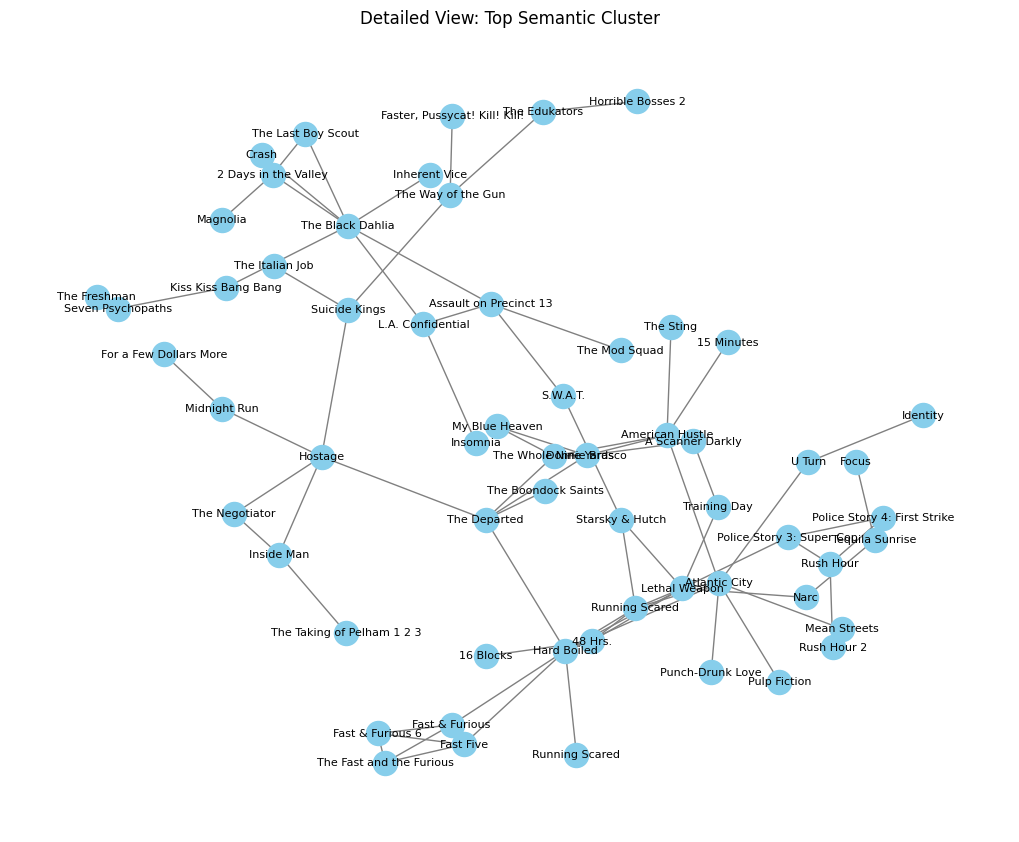

In [25]:
# Example: Visualize only a large cluster
target_cluster = large_clusters[0] 
subgraph = G.subgraph(target_cluster)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph, k=0.3)
nx.draw(subgraph, pos, with_labels=True, 
        labels={n: movie_data[n]['title'] for n in target_cluster},
        node_color='skyblue', edge_color='gray', font_size=8)
plt.title("Detailed View: Top Semantic Cluster")
plt.show()

# Identify Optinal Cutoff
- As cut off is lowered, it creates larger clusters.  There is an optimal cut off where the largest cluster is not too large
- The following algorithm works with two variables "current threshold" and "size limit" for the largest cluster
- In the code below we have set size limit to 2% of the movies 
- We reduce current_threshold till it breaks the size, and then remove the cluster that broke the size limit and publish results

In [26]:
# 1. Sort all pairs by similarity descending (highest to lowest)
sorted_pairs = sorted(similarity_pairs, key=lambda x: x['similarity'], reverse=True)

# 2. Iteratively add edges and monitor the largest cluster size
G_dynamic = nx.Graph()
G_dynamic.add_nodes_from(range(len(movie_data)))

# Set a safety limit: stop if any cluster exceeds a certain % of the total dataset
size_limit = len(movie_data) * 0.02  # Example: Stop if a cluster hits 2% of total movies

print(f"Growing clusters... (Stop limit: {size_limit:.0f} movies)")

for pair in sorted_pairs:
    current_threshold = pair['similarity']
    
    # Add the edge
    G_dynamic.add_edge(pair['index_a'], pair['index_b'])
    
    # Find the largest current cluster
    largest_cc = max(nx.connected_components(G_dynamic), key=len)
    
    # Check if we hit the "gravity" point
    if len(largest_cc) > size_limit:
        print(f"!!! STOPPING: Giant cluster forming at threshold {current_threshold}")
        print(f"Largest cluster size: {len(largest_cc)}")
        # Remove the last edge that triggered the merger
        G_dynamic.remove_edge(pair['index_a'], pair['index_b'])
        break

# Final results after growth
final_clusters = list(nx.connected_components(G_dynamic))
print(f"Final Count: {len([c for c in final_clusters if len(c) > 1])} multi-movie clusters.")

Growing clusters... (Stop limit: 55 movies)
!!! STOPPING: Giant cluster forming at threshold 0.5801
Largest cluster size: 60
Final Count: 225 multi-movie clusters.


In [27]:
# 1. Initialize the cluster column in your filtered dataset
filtered_df['cluster'] = -1

# 2. Iterate through the final_clusters list
# We use enumerate to create a Cluster ID (starting at 1)
for cluster_id, movie_indices in enumerate(final_clusters, start=1):
    # Only assign an ID if the cluster has more than 1 movie
    if len(movie_indices) > 1:
        # Use .iloc or .loc based on how your indices were handled
        # Since final_clusters contains the positional indices of filtered_df:
        filtered_df.iloc[list(movie_indices), filtered_df.columns.get_loc('cluster')] = cluster_id

# 3. Verify the results
cluster_counts = filtered_df['cluster'].value_counts()
print(f"Total multi-movie clusters identified: {len(cluster_counts) - 1}")
print(f"Movies assigned to a cluster: {len(filtered_df[filtered_df['cluster'] != -1])}")

Total multi-movie clusters identified: 225
Movies assigned to a cluster: 731


In [28]:
filtered_df.to_csv("../data/outputs/ABT_Enriched/filtered_ABT.csv")

### Create custom label using LLM

In [ ]:
# Initialize OpenAI client (ensure your API key is set in your environment)
open_ai_model = "gpt-4.1-mini"

cluster_summaries = {}

# We only want to process clusters with a meaningful number of movies (e.g., > 5)
min_cluster_size = 5

cluster_summaries = []
for cluster_id, movie_indices in enumerate(final_clusters, start=1):
    if len(movie_indices) < min_cluster_size:
        continue
        
    # 1. Prepare the data for the prompt
    # We'll take the first 15 movies as a representative sample to save tokens
    sample_indices = list(movie_indices)[:15]
    cluster_movies = filtered_df.iloc[sample_indices]
    
    movie_list_str = ""
    for _, row in cluster_movies.iterrows():
        movie_list_str += f"Title: {row['title']}\nOverview: {row['overview'][:200]}\n\n"

    # 2. Call the OpenAI API
    try:
        response = client.chat.completions.create(
            model = open_ai_model,
            messages=[
                {"role": "system", "content": """You will help user identify a custom genre name for a set of movies.
                   Use the information provided to create a punchy, marketing-friendly custom genre name.
                   
                   Return a JSON object with exactly these keys:
                   - "name": The short, catchy custom genre name.
                   - "description": A brief explanation of why these movies belong together.
                   - "exemplary_overview": A fictitious movie overview that perfectly represents this new genre.
                   - "included_movies": a list of movies that will be included in this genre
                 The included list could be from the movies provided to you as well as other representative movies"""},
                {"role": "user", "content": f"Analyze these movies and return JSON:\n\n{movie_list_str}"}
            ],
            response_format={"type": "json_object"}, # Forces JSON output
            temperature = 0.2
        )
        
        # 3. Parse the JSON response
        raw_content = response.choices[0].message.content
        json_data = json.loads(raw_content)
        
        # 4. Store in our summary dictionary
        cluster_summaries.append({
            "cluster_id": cluster_id,
            "custom_genre": json_data.get("name"),
            "description": json_data.get("description"),
            "exemplar_overview": json_data.get("exemplary_overview"),
            "included_movies": json_data.get("included_movies")})

        print(f"✓ Processed Cluster {cluster_id}: {json_data.get('name')}")
        
        
    except Exception as e:
        print(f"Error processing Cluster {cluster_id}: {e}")

print("\nAI Labeling Complete.")


✓ Processed Cluster 5: Clever Heist Capers
✓ Processed Cluster 8: Global Espionage Thrillers
✓ Processed Cluster 17: Psych-Crime Thrillers
✓ Processed Cluster 18: Samurai Assassin Revenge
✓ Processed Cluster 121: Galactic Saga Adventures
✓ Processed Cluster 136: Viral Apocalypse Thrillers
✓ Processed Cluster 138: Urban Grit & Velocity
✓ Processed Cluster 152: Galactic Frontier Epics
✓ Processed Cluster 185: Heist & Hostage Havoc
✓ Processed Cluster 188: Emotional Southern & New York Dramas
✓ Processed Cluster 228: Robin Hood Rebellion
✓ Processed Cluster 251: Gotham Vigilante Saga
✓ Processed Cluster 289: Whimsical Inventor Adventures
✓ Processed Cluster 400: Twisted Justice Thrillers
✓ Processed Cluster 426: Con & Crossroads
✓ Processed Cluster 468: WWII Undersea & Survival Thrillers
✓ Processed Cluster 492: Wartime Rebel Ops
✓ Processed Cluster 735: Epic Middle-earth Quests
✓ Processed Cluster 750: Nostalgic Coming-of-Age Comedy
✓ Processed Cluster 760: Haunted Havens
✓ Processed Clu

In [47]:
cluster_summaries

[{'cluster_id': 5,
  'custom_genre': 'Clever Heist Capers',
  'description': 'This genre unites films centered around smart, stylish criminals and their intricate schemes, blending suspense, wit, and high-stakes cons or heists. These movies focus on the thrill of the plan, the dynamics within the crew, and the clever twists that keep audiences guessing.',
  'exemplar_overview': 'When a seasoned thief assembles a diverse team to pull off the ultimate heist, they must outsmart rival criminals and law enforcement alike. As tensions rise and loyalties are tested, the crew navigates double-crosses and unexpected obstacles to claim their prize and secure their freedom.',
  'included_movies': ['Heist',
   'To Catch a Thief',
   'Trading Places',
   'Heat',
   "White Men Can't Jump",
   'Gone in Sixty Seconds',
   'The Italian Job',
   'The Town',
   'Small Time Crooks',
   "Ocean's Eleven",
   'Inside Man',
   'Logan Lucky']},
 {'cluster_id': 8,
  'custom_genre': 'Global Espionage Thrillers',

In [48]:
output_path = "../data/outputs/custom_genre_temp_0.2.json"

# Open the file in 'w' (write) mode
with open(output_path, "w") as json_file:
    # Use .dump() to save the list directly to the file
    # indent=4 makes the file human-readable for your students
    json.dump(cluster_summaries, json_file, indent=4)

df_cluster_summaries = pd.DataFrame.from_dict(cluster_summaries)
df_cluster_summaries.to_csv("../data/outputs/custom_genre_temp_0.2.csv")

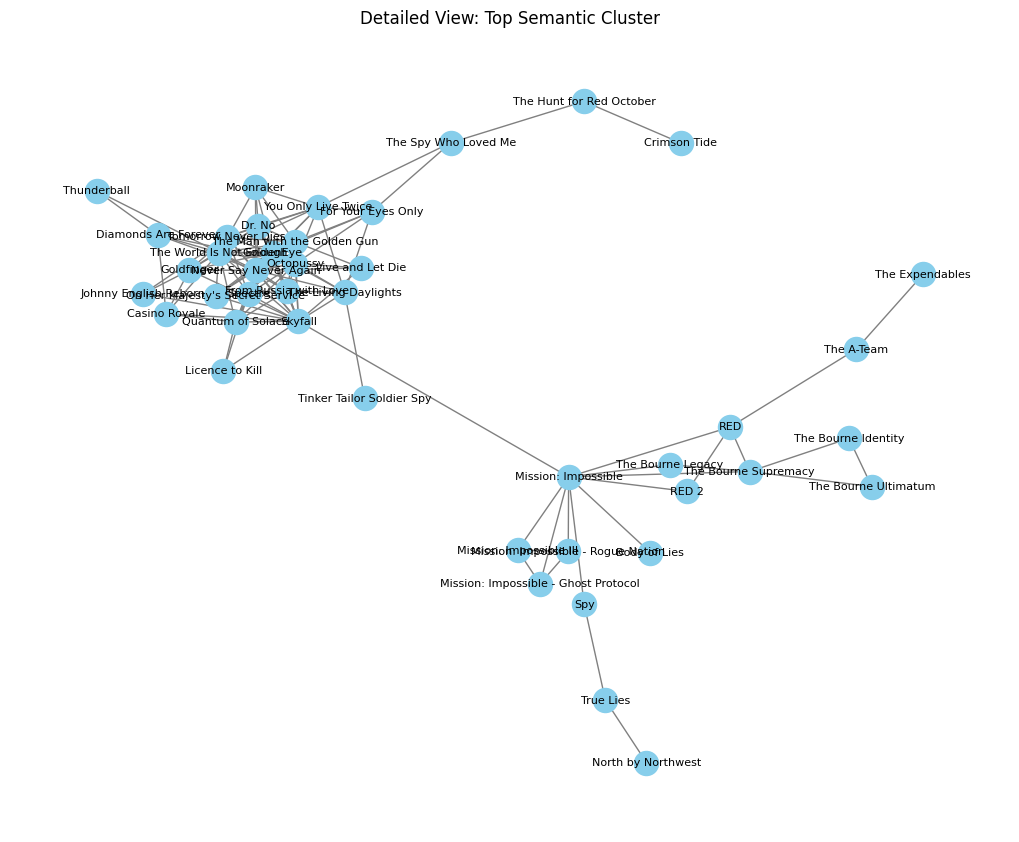

In [55]:
# Example: Visualize only a large cluster
target_cluster = final_clusters[7] 
subgraph = G.subgraph(target_cluster)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph, k=0.3)
nx.draw(subgraph, pos, with_labels=True, 
        labels={n: movie_data[n]['title'] for n in target_cluster},
        node_color='skyblue', edge_color='gray', font_size=8)
plt.title("Detailed View: Top Semantic Cluster")
plt.show()

## Configuration

In [8]:
display_config()

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               ✓ Set
  Google               ✗ Not set
  Mistral              ✗ Not set
  Anthropic            ✗ Not set
  Serper (Web Search)  ✓ Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## Load Use Case

In [128]:
# Load use case configuration
use_case_file = "../data/input/use_case_Movie_Recommendation.xlsx"
use_case_config = load_use_case_config(use_case_file)
system_prompt = use_case_config.get("agent_prompt", "You are a helpful movie assistant")

print(f"✓ System prompt loaded")

✓ Use case loaded: ../data/input/use_case_Movie_Recommendation.xlsx
  Components: user, agent_prompt, url
✓ System prompt loaded


In [129]:
# Load ABT Data file
ABT_File= "../data/outputs/ABT_Enriched/filtered_ABT.csv"

df = pd.read_csv(ABT_File)

print(df.head)


<bound method NDFrame.head of       Unnamed: 0.1  Unnamed: 0  movieId                        title  \
0                0           0        1                    Toy Story   
1                1           1        2                      Jumanji   
2                2           2        3             Grumpier Old Men   
3                4           4        5  Father of the Bride Part II   
4                5           5        6                         Heat   
...            ...         ...      ...                          ...   
2758          9647        9647   180031           The Shape of Water   
2759          9656        9656   180985         The Greatest Showman   
2760          9683        9683   183897                 Isle of Dogs   
2761          9709        9709   187593                   Deadpool 2   
2762          9710        9710   187595      Solo: A Star Wars Story   

                                 movielens_genres  avg_rating  \
0     Adventure|Animation|Children|Comed

## Extract URLs from Excel

In [130]:
# Extract URLs from use case file
url_string = use_case_config.get("url", "")

if url_string and url_string.strip():
    # Parse comma-separated URLs
    urls = [url.strip() for url in url_string.split(",") if url.strip()]
    print(f"✓ Found {len(urls)} URLs in use case file:")
    for i, url in enumerate(urls, 1):
        print(f"  {i}. {url}")
else:
    urls = []
    print("⚠️ No URLs found in use case file")

✓ Found 3 URLs in use case file:
  1. https://IMDB.com
  2. https://www.themoviedb.org
  3. https://grouplens.org/datasets/movielens/


## Build Curated Knowledge Base from Excel URLs

This creates a searchable knowledge base from the URLs in your Excel file.

In [27]:
url_retriever = None

if urls:
    try:
        print(f"\n📥 Loading content from {len(urls)} URLs...")
        
        # Load documents from URLs
        loader = WebBaseLoader(urls)
        documents = loader.load()
        print(f"  ✓ Loaded {len(documents)} documents")
        
        # Split into chunks
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000,
            chunk_overlap=200
        )
        splits = text_splitter.split_documents(documents)
        print(f"  ✓ Created {len(splits)} text chunks")
        
        # Create vector store
        embeddings = OpenAIEmbeddings()
        vectorstore = FAISS.from_documents(splits, embeddings)
        print(f"  ✓ Vector store created")
        
        # Create retriever
        url_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
        print(f"  ✓ Retriever ready")
        
        print("\n✅ Curated knowledge base built from Excel URLs!")
        
    except Exception as e:
        print(f"\n❌ Error building knowledge base: {str(e)}")
        print("Tools will still work, but curated_knowledge_search will be limited")
        url_retriever = None
else:
    print("\n⚠️ Skipping knowledge base (no URLs in Excel)")
    print("You can still use search_web and fetch_url_content")


📥 Loading content from 3 URLs...
  ✓ Loaded 3 documents
  ✓ Created 14 text chunks
  ✓ Vector store created
  ✓ Retriever ready

✅ Curated knowledge base built from Excel URLs!


## Define Tools

Three powerful tools for comprehensive movie information retrieval.

In [28]:
# Tool 1: General Web Search
@tool
def search_web(query: str) -> str:
    """
    Search the web for current movie information, news, and reviews.
    
    Best for:
    - Current information (box office, new releases)
    - General queries about movies
    - Recent news and reviews
    - When you need real-time data
    
    Args:
        query: Search query
        
    Returns:
        Search results from the web
    """
    try:
        search = GoogleSerperAPIWrapper()
        return search.run(query)
    except Exception as e:
        return f"Search error: {str(e)}"

print("✓ Tool 1: search_web defined")

✓ Tool 1: search_web defined


In [29]:
# Tool 2: Curated Knowledge Search (from Excel URLs)
@tool
def curated_knowledge_search(query: str) -> str:
    """
    Search the curated knowledge base built from URLs in the Excel file.
    
    Best for:
    - Information from pre-loaded trusted sources
    - Queries about content in the configured URLs
    - Domain-specific knowledge from IMDB, TMDB, etc.
    
    Args:
        query: Search query
        
    Returns:
        Relevant content from curated sources
    """
    if url_retriever is None:
        return "Curated knowledge base not available. No URLs were loaded from Excel file."
    
    try:
        docs = url_retriever.invoke(query)
        results = []
        for doc in docs:
            source = doc.metadata.get('source', 'Unknown')
            content = doc.page_content
            results.append(f"Source: {source}\nContent: {content}")
        
        return "\n\n---\n\n".join(results)
    except Exception as e:
        return f"Error searching curated knowledge: {str(e)}"

print("✓ Tool 2: curated_knowledge_search defined")

✓ Tool 2: curated_knowledge_search defined


In [30]:
# Tool 3: Dynamic URL Fetch 
@tool  
def fetch_url_content(url: str) -> str:
    """
    Fetch and extract content from any specific URL on-demand.
    
    Best for:
    - When user provides a specific URL (e.g., https://www.imdb.com/title/tt0113041)
    - Need fresh content from a specific webpage
    - Retrieving data from URLs not in the curated knowledge base
    - Ad-hoc queries about specific movie pages
    
    Args:
        url: Full URL to fetch (must include https:// or http://)
        
    Returns:
        Extracted text content from the URL
    
    Examples:
    - fetch_url_content("https://www.imdb.com/title/tt0113041")
    - fetch_url_content("https://www.themoviedb.org/movie/11862")
    """
    try:
        print(f"  🌐 Fetching: {url}")
        
        # Load the URL
        loader = WebBaseLoader([url])
        documents = loader.load()
        
        if documents:
            # Extract content (limit to 5000 chars to avoid token limits)
            content = documents[0].page_content[:5000]
            
            # Add metadata if available
            metadata = documents[0].metadata
            source_info = f"Source: {metadata.get('source', url)}"
            
            return f"{source_info}\n\nContent:\n{content}"
        else:
            return f"No content could be extracted from {url}"
            
    except Exception as e:
        return f"Error fetching {url}: {str(e)}\n\nPlease verify the URL is valid and accessible."

print("✓ Tool 3: fetch_url_content defined")

✓ Tool 3: fetch_url_content defined


In [31]:
# Configure tools based on availability
if url_retriever is not None:
    tools = [search_web, curated_knowledge_search, fetch_url_content]
    print(f"\n✅ All 3 tools configured:")
    print("  1. search_web - General web search")
    print("  2. curated_knowledge_search - Pre-loaded URLs from Excel")
    print("  3. fetch_url_content - Dynamic URL fetching")
else:
    tools = [search_web, fetch_url_content]
    print(f"\n✅ 2 tools configured:")
    print("  1. search_web - General web search")
    print("  2. fetch_url_content - Dynamic URL fetching")
    print("  (curated_knowledge_search not available - no URLs in Excel)")


✅ All 3 tools configured:
  1. search_web - General web search
  2. curated_knowledge_search - Pre-loaded URLs from Excel
  3. fetch_url_content - Dynamic URL fetching


## Initialize LLM

In [32]:
llm = load_llm_from_env()
model = llm.bind_tools(tools)

print("✓ LLM initialized with tools")

🤖 Loading LLM: openai / gpt-4.1-mini
✓ LLM initialized with tools


## Build Agent Graph with Memory

In [33]:
def call_model(state: MessagesState):
    """Agent node that decides which tools to use."""
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    return {"messages": [model.invoke(messages)]}

def should_continue(state: MessagesState):
    """Decision function: continue to tools or end."""
    last_message = state["messages"][-1]
    return "tools" if last_message.tool_calls else END

# Build workflow
workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))
workflow.set_entry_point("agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", END: END}
)
workflow.add_edge("tools", "agent")

# Compile with memory
app = workflow.compile(checkpointer=MemorySaver())

print("✓ Agent graph with memory compiled")
app = workflow.compile()



✓ Agent graph with memory compiled


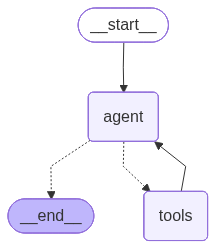

In [34]:
display(Image(app.get_graph().draw_mermaid_png()))

## Chat Helper Function

Use this to have conversations with the assistant.

In [35]:
def chat(user_input: str, thread_id: str = "default", verbose: bool = False) -> str:
    """
    Chat with the movie assistant.
    
    Args:
        user_input: Your message/query
        thread_id: Conversation thread ID (use same ID to continue conversation)
        verbose: Show which tools are being used
        
    Returns:
        Assistant's response
    """
    config = {"configurable": {"thread_id": thread_id}}
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Query: {user_input[:100]}...")
        print(f"{'='*70}")
        tools_used = []
    
    result = None
    for event in app.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config,
        stream_mode="values"
    ):
        result = event
        if verbose:
            last_message = event["messages"][-1]
            if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
                for tool_call in last_message.tool_calls:
                    tool_name = tool_call['name']
                    if tool_name not in tools_used:
                        tools_used.append(tool_name)
                        print(f"  🔧 Using: {tool_name}")
    
    if verbose and tools_used:
        print(f"  ✓ Tools used: {', '.join(tools_used)}")
    
    return result["messages"][-1].content

print("\n🎬 Movie Chatbot Ready!")
print("\nUsage:")
print("  response = chat('Your question')")
print("  response = chat('Follow-up', thread_id='same_thread')")
print("  response = chat('Your question', verbose=True)  # See tool usage")


🎬 Movie Chatbot Ready!

Usage:
  response = chat('Your question')
  response = chat('Follow-up', thread_id='same_thread')
  response = chat('Your question', verbose=True)  # See tool usage


## Test 1: Dynamic URL Fetch (Specific IMDB URL)

Test the new fetch_url_content tool with a specific movie page.

In [36]:
# Test fetching specific IMDB URL
thread = "test1"

query1 = """Retrieve the following data from the URL https://www.imdb.com/title/tt0113041:
- Title
- Release year
- Genres
- IMDb rating
- Cast & crew
- Awards (if available)"""

print("User:", query1)
print("\n" + "-"*70 + "\n")

response1 = chat(query1, thread_id=thread, verbose=True)
print(f"\nBot: {response1}")

User: Retrieve the following data from the URL https://www.imdb.com/title/tt0113041:
- Title
- Release year
- Genres
- IMDb rating
- Cast & crew
- Awards (if available)

----------------------------------------------------------------------


Query: Retrieve the following data from the URL https://www.imdb.com/title/tt0113041:
- Title
- Release yea...
  🔧 Using: fetch_url_content
  🌐 Fetching: https://www.imdb.com/title/tt0113041
  ✓ Tools used: fetch_url_content

Bot: It seems that the content from the IMDb page for the movie with the ID tt0113041 could not be retrieved due to JavaScript being disabled or a verification requirement on the page. Would you like me to try searching for the movie details using another method? Also, could you please confirm the movie title or provide any other details you know about it?


## Test 2: Dynamic URL Fetch (Specific TMDB URL)

Test with a different movie database.

In [37]:
# Test fetching specific TMDB URL
thread = "test2"

query2 = """Retrieve the following data from the URL https://www.themoviedb.org/movie/11862:
- Genres
- Cast & crew
- Keywords
- Popularity scores
- Overview"""

print("\nUser:", query2)
print("\n" + "-"*70 + "\n")

response2 = chat(query2, thread_id=thread, verbose=True)
print(f"\nBot: {response2}")


User: Retrieve the following data from the URL https://www.themoviedb.org/movie/11862:
- Genres
- Cast & crew
- Keywords
- Popularity scores
- Overview

----------------------------------------------------------------------


Query: Retrieve the following data from the URL https://www.themoviedb.org/movie/11862:
- Genres
- Cast & c...
  🔧 Using: fetch_url_content
  🌐 Fetching: https://www.themoviedb.org/movie/11862
  ✓ Tools used: fetch_url_content

Bot: Here is the data retrieved from the URL for the movie "Father of the Bride Part II" (1995):

- Genres: Comedy, Family
- Cast & Crew:
  - Director, Screenplay: Charles Shyer
  - Screenplay: Nancy Meyers
  - Top Billed Cast:
    - Steve Martin as George Banks
    - Diane Keaton as Nina Banks
    - Martin Short as Franck Eggelhoffer
    - Kimberly Williams-Paisley as Annie Banks-MacKenzie
    - George Newbern as Bryan MacKenzie
    - Kieran Culkin as Matty Banks
    - BD Wong as Howard Weinstein
    - Peter Michael Goetz as John MacKenzi

## Test 3: Conversation with Memory

Test that memory works across multiple queries.

In [38]:
# Test conversation memory
thread = "memory_test"

print("\n" + "="*70)
print("Testing Conversational Memory")
print("="*70)

# Query 1
query_a = "Tell me about Christopher Nolan movies"
print(f"\nUser: {query_a}")
response_a = chat(query_a, thread_id=thread)
print(f"Bot: {response_a[:200]}...")

# Query 2 (should remember context)
query_b = "Which one should I watch first?"
print(f"\nUser: {query_b}")
response_b = chat(query_b, thread_id=thread)
print(f"Bot: {response_b[:200]}...")

# Query 3 (still remembers)
query_c = "Why is that one special?"
print(f"\nUser: {query_c}")
response_c = chat(query_c, thread_id=thread)
print(f"Bot: {response_c[:200]}...")


Testing Conversational Memory

User: Tell me about Christopher Nolan movies
Bot: Christopher Nolan is a renowned filmmaker known for his complex storytelling, innovative narrative structures, and visually striking films. His movies often explore themes of time, memory, identity, a...

User: Which one should I watch first?
Bot: To help you decide which movie to watch first, could you please tell me the titles of the movies you're considering? Also, what kind of mood or genre are you in the mood for?...

User: Why is that one special?
Bot: Could you please specify which movie or topic you are referring to as "that one"? This will help me provide a precise answer about why it might be special....


## Test 4: Compare Different Search Methods

See how the different tools work.

In [ ]:
thread = "comparison"

print("\n" + "="*70)
print("Comparing Search Methods")
print("="*70)

# This should use web search for current info
query = "What are the top movies in theaters right now?"
print(f"\nQuery: {query}")
print("Expected tool: search_web (for current info)")
response = chat(query, thread_id=thread, verbose=True)
print(f"\nResponse: {response[:250]}...")

## Interactive Testing

Try your own queries!

In [39]:
# YOUR TURN: Test with your own URL
my_url = "https://www.imdb.com/title/tt0111161"  # The Shawshank Redemption
my_query = f"Get information from {my_url} including title, year, rating, and plot summary"

print(f"User: {my_query}")
response = chat(my_query, thread_id="my_test", verbose=True)
print(f"\nBot: {response}")

User: Get information from https://www.imdb.com/title/tt0111161 including title, year, rating, and plot summary

Query: Get information from https://www.imdb.com/title/tt0111161 including title, year, rating, and plot su...
  🔧 Using: fetch_url_content
  🌐 Fetching: https://www.imdb.com/title/tt0111161
  ✓ Tools used: fetch_url_content

Bot: It seems that the content from the IMDb page for the movie with the ID tt0111161 could not be retrieved due to JavaScript being disabled on the page. Would you like me to try searching for the information about this movie from other sources? Also, just to confirm, are you looking for details about "The Shawshank Redemption" (which is the movie with this IMDb ID)?


## Summary

### ✅ What We Built:
- **Three-tool system** for comprehensive movie information
- **search_web** - Current information and general queries
- **curated_knowledge_search** - Pre-loaded URLs from Excel
- **fetch_url_content** - Dynamic URL fetching (NEW!)
- **Conversational memory** - Maintains context
- **Thread-based conversations** - Multiple independent chats

### 🎯 When to Use Each Tool:
| Tool | Best For | Example |
|------|----------|---------|
| **search_web** | Current info, news, general queries | "Top movies this week" |
| **curated_knowledge_search** | Pre-loaded sources from Excel | General movie database queries |
| **fetch_url_content** | Specific URLs provided by user | "Get data from https://..." |

### 🆕 What's New:
- Can now fetch ANY URL on-demand
- Perfect for specific IMDB, TMDB, or other movie pages
- Works alongside existing tools
- Still maintains conversation memory

### 📝 Usage Tips:
1. **For specific URLs**: Provide the full URL in your query
2. **For general info**: Let the agent choose the best tool
3. **For memory**: Use same thread_id to continue conversations
4. **For debugging**: Use verbose=True to see which tools are used